# DQN Trading Agent

The LSTM signal is computed **rolling**: at each day `t`, the model uses the last 60 days of data to predict whether the price will be higher 20 days later. So day 0 predicts day 20, day 1 predicts day 21, and so on.

**Files required:**
- `datasets/nasdaq_multivariate.csv`
- `models/stage1_model.pth`
- `models/stage1_scaler.joblib`

## 1. Install Dependencies

In [37]:
%pip install stable-baselines3[extra] gymnasium joblib -q

## 2. Mount Google Drive

Upload the following files to your Google Drive under a folder called `CSC246/`:
- `CSC246/datasets/nasdaq_multivariate.csv`
- `CSC246/models/stage1_model.pth`
- `CSC246/models/stage1_scaler.joblib`

In [38]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Adjust this path if your folder is named differently
BASE_DIR = '/content/drive/MyDrive/'

CSV_PATH      = os.path.join(BASE_DIR, 'datasets/nasdaq_multivariate.csv')
SCALER_PATH   = os.path.join(BASE_DIR, 'models/stage1_scaler.joblib')
WEIGHTS_PATH  = os.path.join(BASE_DIR, 'models/stage1_model.pth')

# Output paths (saved back to Drive)
DQN_SAVE      = os.path.join(BASE_DIR, 'models/dqn_nasdaq_252.zip')
CURVE_SAVE    = os.path.join(BASE_DIR, 'results/dqn_252_reward_curve.png')
EQUITY_SAVE   = os.path.join(BASE_DIR, 'results/dqn_252_equity_curves.png')

os.makedirs(os.path.join(BASE_DIR, 'models'),  exist_ok=True)
os.makedirs(os.path.join(BASE_DIR, 'results'), exist_ok=True)

print('Drive mounted. Checking files...')
for p in [CSV_PATH, SCALER_PATH, WEIGHTS_PATH]:
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'  [{status}] {p}')

Mounted at /content/drive
Drive mounted. Checking files...
  [OK] /content/drive/MyDrive/datasets/nasdaq_multivariate.csv
  [OK] /content/drive/MyDrive/models/stage1_scaler.joblib
  [OK] /content/drive/MyDrive/models/stage1_model.pth


## 3. Stage 1 — LSTM Model Definition

The `ReturnPredictor` LSTM predicts whether the NASDAQ will be higher 20 days from now.

In [39]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Feature columns (must match what the scaler was fitted on)
FEATURE_COLS = [
    'Return', 'Return_lag1', 'Return_lag2', 'Return_lag5',
    'Price_SMA20', 'Price_SMA50',
    'RSI_14', 'MACD_Hist', 'BB_pos', 'BB_width',
    'Volume_ratio', 'Volume_change',
    'VIX', 'TNX', 'FedRate', 'CPI_MoM',
    'Regime', 'VIX_percentile',
    'Momentum_20d', 'Momentum_60d', 'Momentum_252d',
    'Volatility_20d', 'ATR_14',
    'Yield_slope', 'Dist_52w_high', 'Dist_52w_low',
    'VIX_change5', 'Gap',
    'FedRate_chg20', 'FedRate_chg60',
]
MACRO_COLS = [
    'FedRate', 'FedRate_chg20', 'FedRate_chg60',
    'TNX', 'Yield_slope', 'VIX', 'VIX_percentile',
]

WINDOW_SIZE = 60
HIDDEN_SIZE = 32
DROPOUT     = 0.3


class ReturnPredictor(nn.Module):
    def __init__(self, n_features, n_macro, hidden=32, dropout=0.3):
        super().__init__()
        self.lstm      = nn.LSTM(n_features, hidden, num_layers=1, batch_first=True)
        self.macro_mlp = nn.Sequential(nn.Linear(n_macro, 16), nn.ReLU())
        self.head      = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden + 16, 1))

    def forward(self, x_seq, macro):
        lstm_out, _ = self.lstm(x_seq)
        h_last      = lstm_out[:, -1, :]
        m           = self.macro_mlp(macro)
        return self.head(torch.cat([h_last, m], dim=-1)).squeeze(-1)


def load_and_engineer_features(csv_path):
    df = pd.read_csv(csv_path)
    print(f'Loaded {len(df)} rows, {df.shape[1]} columns')

    df['Forward_20d']   = df['Close'].shift(-20) / df['Close'] - 1
    df['target']        = (df['Forward_20d'] > df['Forward_20d'].median()).astype(int)
    df['Regime']        = (df['Close'] > df['Close'].rolling(60).mean()).astype(int)
    df['Momentum_20d']  = df['Close'] / df['Close'].shift(20) - 1
    df['Momentum_60d']  = df['Close'] / df['Close'].shift(60) - 1
    df['Momentum_252d'] = df['Close'] / df['Close'].shift(252) - 1
    df['Dist_52w_high'] = df['Close'] / df['Close'].rolling(252).max() - 1
    df['Dist_52w_low']  = df['Close'] / df['Close'].rolling(252).min() - 1
    df['Volatility_20d']= df['Return'].rolling(20).std()
    df['ATR_14']        = (df['High'] - df['Low']).rolling(14).mean() / df['Close']
    df['VIX_percentile']= df['VIX'].rolling(252).rank(pct=True)
    df['VIX_change5']   = df['VIX'].diff(5)
    df['Yield_slope']   = df['TNX'] - df['FedRate']
    df['FedRate_chg20'] = df['FedRate'].diff(20)
    df['FedRate_chg60'] = df['FedRate'].diff(60)
    df['Gap']           = df['Open'] / df['Close'].shift(1) - 1

    df.dropna(inplace=True)
    print(f'After dropna: {len(df)} rows  |  target positive rate: {df["target"].mean():.3f}')
    return df


def load_lstm_model(weights_path):
    model = ReturnPredictor(len(FEATURE_COLS), len(MACRO_COLS), hidden=HIDDEN_SIZE, dropout=DROPOUT)
    state = torch.load(weights_path, map_location='cpu')
    model.load_state_dict(state)
    model.eval()
    print(f'LSTM model loaded from {weights_path}')
    return model


print('Stage 1 definitions loaded.')

Device: cuda
Stage 1 definitions loaded.


## 4. LSTM Inference — Rolling 20-Day Predictions

For each day `t`, the LSTM uses the **last 60 days** of features to predict whether the price will be higher **20 days later**. This gives a rolling signal:
- Day 0 predicts day 20
- Day 1 predicts day 21
- Day 2 predicts day 22
- ...

Raw probabilities are concentrated (mean ≈ 0.83, std ≈ 0.08), so they are z-scored then mapped through tanh to spread them across [0, 1].

In [40]:
def generate_prob_series(df, model, scaler, window=WINDOW_SIZE):# -> tuple[Any, Any, NDArray[floating[_32Bit]]]:
    """
    Run LSTM inference over a DataFrame.

    Rolling prediction: at day t, uses data[t-window:t] to predict
    whether price at t+20 > price at t. So:
      - probs[0] = prediction for day 0 about day 20
      - probs[1] = prediction for day 1 about day 21
      - etc.

    Returns
    -------
    probs_norm     : np.ndarray (N,)   — normalised LSTM probs in [0, 1]
    prices         : np.ndarray (N,)   — Close prices aligned to probs
    extra_features : np.ndarray (N, 3) — [recent_5d_return_norm, vol_norm, regime]
    """
    scaled    = df[FEATURE_COLS].values.copy().astype(np.float32)
    scaled    = scaler.transform(scaled)
    macro_raw = df[MACRO_COLS].values.astype(np.float32)

    # Rolling LSTM inference: each step t uses data[t-window:t]
    raw_probs = []
    with torch.no_grad():
        for i in range(window, len(df)):
            x_seq = torch.tensor(scaled[i - window : i]).unsqueeze(0)
            macro = torch.tensor(macro_raw[i - 1]).unsqueeze(0)
            logit = model(x_seq, macro)
            raw_probs.append(torch.sigmoid(logit).item())

    raw_probs = np.array(raw_probs, dtype=np.float32)

    # Z-score then tanh to spread concentrated signal across [0, 1]
    z          = (raw_probs - raw_probs.mean()) / (raw_probs.std() + 1e-8)
    probs_norm = (0.5 + 0.5 * np.tanh(z)).astype(np.float32)

    prices = df['Close'].values[window:].astype(np.float32)

    # Extra features
    close = df['Close'].values.astype(np.float64)
    ret5  = np.zeros(len(df), dtype=np.float32)
    ret5[5:] = (close[5:] - close[:-5]) / close[:-5]
    recent_5d_norm = (0.5 + 0.5 * np.tanh(ret5[window:] / 0.05)).astype(np.float32)

    vol_raw  = df['Volatility_20d'].values[window:].astype(np.float32)
    vol_norm = np.clip(vol_raw / 0.03, 0.0, 1.0).astype(np.float32)

    regime = np.array(df['Regime'].values[window:], dtype=np.float32)

    extra_features = np.stack([recent_5d_norm, vol_norm, regime], axis=1).astype(np.float32)

    print(f'Generated {len(probs_norm)} steps  |  '
          f'raw prob: mean={raw_probs.mean():.3f} std={raw_probs.std():.3f}  |  '
          f'norm prob: mean={probs_norm.mean():.3f} std={probs_norm.std():.3f}')
    return probs_norm, prices, extra_features


print('LSTM inference function defined.')

LSTM inference function defined.


## 5. Trading Environment

Each episode starts at a random position in the training data and runs for 252 steps. The agent chooses from 31 discrete position sizes ranging from -100% (fully short) to +200% (2x leveraged long).

In [41]:
import gymnasium as gym
from gymnasium import spaces

EPISODE_LEN    = 252
SIGNAL_BONUS_W = 20
VOL_PENALTY_W  = 0
MARGIN_RATE    = 0.02 / 252

N_ACTIONS  = 31
ACTION_MAP = {i: (i - 10) * 0.1 for i in range(N_ACTIONS)}


class NASDAQTradingEnv(gym.Env):
    metadata = {'render_modes': []}

    def __init__(self, prices, probs, extra_features,
                 initial_cash=10_000, episode_len=EPISODE_LEN,
                 signal_bonus_w=SIGNAL_BONUS_W, vol_penalty_w=VOL_PENALTY_W):
        super().__init__()
        assert len(prices) == len(probs) == len(extra_features)
        assert extra_features.ndim == 2 and extra_features.shape[1] == 3

        self.prices         = prices.astype(np.float32)
        self.probs          = probs.astype(np.float32)
        self.extra_features = extra_features.astype(np.float32)
        self.initial_cash   = float(initial_cash)
        self.episode_len    = episode_len
        self.signal_bonus_w = signal_bonus_w
        self.vol_penalty_w  = vol_penalty_w

        self.observation_space = spaces.Box(
            low  = np.array([0., 0., 0., -1., -1., 0.], dtype=np.float32),
            high = np.array([1., 1., 1.,  2.,  2., 1.], dtype=np.float32),
        )
        self.action_space = spaces.Discrete(N_ACTIONS)

        self._start = self._step_count = 0
        self._cash  = self.initial_cash
        self._shares = 0.0

    def _current_price(self):
        return float(self.prices[self._start + self._step_count])

    def _total_assets(self):
        return self._cash + self._shares * self._current_price()

    def _get_obs(self):
        idx        = self._start + self._step_count
        price      = self._current_price()
        total      = self._total_assets()
        pos_ratio  = (self._shares * price / total) if total > 0 else 0.0
        cash_ratio = (self._cash / total)            if total > 0 else 1.0
        obs = np.array([
            self.probs[idx],
            self.extra_features[idx, 0],
            self.extra_features[idx, 1],
            pos_ratio,
            cash_ratio,
            self.extra_features[idx, 2],
        ], dtype=np.float32)
        obs[0:3] = np.clip(obs[0:3], 0.0, 1.0)
        obs[3]   = np.clip(obs[3],  -1.0, 2.0)
        obs[4]   = np.clip(obs[4],  -1.0, 2.0)
        obs[5]   = np.clip(obs[5],   0.0, 1.0)
        return obs

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        max_start        = len(self.prices) - self.episode_len - 1
        self._start      = int(self.np_random.integers(0, max_start)) if max_start > 0 else 0
        self._step_count = 0
        self._cash       = self.initial_cash
        self._shares     = 0.0
        return self._get_obs(), {}

    def step(self, action):
        target_pos  = ACTION_MAP[int(action)]
        price_prev  = self._current_price()
        reward_idx  = self._start + self._step_count
        signal_t    = float(self.probs[reward_idx])
        vol_t       = float(self.extra_features[reward_idx, 1])

        total       = self._total_assets()
        current_pos = (self._shares * price_prev / total) if total > 0 else 0.0
        delta       = target_pos - current_pos
        shares_delta = (delta * total) / price_prev

        if shares_delta > 0:
            self._shares += shares_delta
            self._cash   -= shares_delta * price_prev
        elif shares_delta < 0:
            self._shares += shares_delta
            self._cash   -= shares_delta * price_prev

        self._step_count += 1
        price_today  = self._current_price()
        daily_return = (price_today - price_prev) / price_prev

        if self._cash < 0:
            self._cash -= abs(self._cash) * MARGIN_RATE

        total_new     = self._total_assets()
        pos_ratio_new = (self._shares * price_today / total_new) if total_new > 0 else 0.0

        portfolio_return = daily_return * pos_ratio_new
        reward_base = portfolio_return * 100

        desired   = 2.0 * signal_t - 1.0
        alignment = (1.0 + pos_ratio_new * desired) / 2.0
        vol_penalty = vol_t * abs(pos_ratio_new) * abs(daily_return) * self.vol_penalty_w
        bonus = alignment * abs(daily_return) * self.signal_bonus_w

        reward = reward_base + bonus - vol_penalty

        terminated = self._step_count >= self.episode_len
        return self._get_obs(), float(reward), terminated, False, {}


print(f'Trading environment defined  |  EPISODE_LEN={EPISODE_LEN} days')

Trading environment defined  |  EPISODE_LEN=252 days


## 6. Load Data & Generate LSTM Signals

In [42]:
import joblib

def set_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seeds(42)

# Load data and engineer features
df = load_and_engineer_features(CSV_PATH)

# Training split: 1990-2019, excluding 2002 (dot-com) and 2008 (GFC)
mask = (
    (df['Date'] >= '1990-01-01') &
    (df['Date'] <  '2019-01-01') &
    ~((df['Date'] >= '2002-01-01') & (df['Date'] < '2003-01-01')) &
    ~((df['Date'] >= '2008-01-01') & (df['Date'] < '2009-01-01'))
)
rl_train_df = df[mask].reset_index(drop=True)
print(f'RL train split: {len(rl_train_df)} rows  (1990-2019, excl. 2002 & 2008)')

# Load scaler and LSTM
scaler     = joblib.load(SCALER_PATH)
model_lstm = load_lstm_model(WEIGHTS_PATH)

# Generate rolling LSTM probability series
print('\nGenerating rolling LSTM signals for training data...')
rl_probs, rl_prices, rl_extra = generate_prob_series(rl_train_df, model_lstm, scaler)
print(f'Train arrays — probs: {rl_probs.shape}, prices: {rl_prices.shape}, extra: {rl_extra.shape}')
print(f'\nNote: With EPISODE_LEN={EPISODE_LEN}, valid start positions: {len(rl_prices) - EPISODE_LEN - 1}')

Loaded 9322 rows, 37 columns
After dropna: 8848 rows  |  target positive rate: 0.505
RL train split: 6551 rows  (1990-2019, excl. 2002 & 2008)
LSTM model loaded from /content/drive/MyDrive/models/stage1_model.pth

Generating rolling LSTM signals for training data...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Generated 6491 steps  |  raw prob: mean=0.643 std=0.120  |  norm prob: mean=0.486 std=0.319
Train arrays — probs: (6491,), prices: (6491,), extra: (6491, 3)

Note: With EPISODE_LEN=252, valid start positions: 6238


## 7. Train DQN

In [43]:
import matplotlib.pyplot as plt
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback


TOTAL_TIMESTEPS        = 1_000_000
BUFFER_SIZE            = 100_000
LEARNING_STARTS        = 5_000
BATCH_SIZE             = 128
LEARNING_RATE          = 1e-4
GAMMA                  = 0.97
TARGET_UPDATE_INTERVAL = 1_000
EXPLORATION_FRACTION   = 0.3
EXPLORATION_FINAL_EPS  = 0.05
TRAIN_FREQ             = 4
GRADIENT_STEPS         = 1
NET_ARCH               = [256, 256]
SEED                   = 42


class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.ep_rewards = []
        self._ep_buffer = 0.0

    def _on_step(self):
        self._ep_buffer += float(self.locals['rewards'][0])
        if self.locals['dones'][0]:
            self.ep_rewards.append(self._ep_buffer)
            self._ep_buffer = 0.0
        return True


# Validate environment

def make_env():
    return NASDAQTradingEnv(rl_prices, rl_probs, rl_extra)

env = make_env()
print('Running env_checker...')
check_env(env, warn=True)
print('env_checker passed.')

# Train
print(f'\nTraining DQN for {TOTAL_TIMESTEPS:,} timesteps  '
      f'(episode_len={EPISODE_LEN}, buffer={BUFFER_SIZE:,}, net_arch={NET_ARCH})...')
callback = RewardCallback()

dqn = DQN(
    'MlpPolicy',
    env,
    buffer_size            = BUFFER_SIZE,
    learning_starts        = LEARNING_STARTS,
    batch_size             = BATCH_SIZE,
    learning_rate          = LEARNING_RATE,
    gamma                  = GAMMA,
    target_update_interval = TARGET_UPDATE_INTERVAL,
    exploration_fraction   = EXPLORATION_FRACTION,
    exploration_final_eps  = EXPLORATION_FINAL_EPS,
    train_freq             = TRAIN_FREQ,
    gradient_steps         = GRADIENT_STEPS,
    policy_kwargs          = dict(net_arch=NET_ARCH),
    seed                   = SEED,
    verbose                = 1,
    device                 = DEVICE
)
dqn.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callback)
print('Training complete.')

dqn.save(DQN_SAVE)
print(f'Policy saved to {DQN_SAVE}')

Running env_checker...
env_checker passed.

Training DQN for 1,000,000 timesteps  (episode_len=252, buffer=100,000, net_arch=[256, 256])...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 252      |
|    ep_rew_mean      | 42.7     |
|    exploration_rate | 0.997    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 10503    |
|    time_elapsed     | 0        |
|    total_timesteps  | 1008     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 252      |
|    ep_rew_mean      | 28.6     |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 10502    |
|    time_elapsed     | 0        |
|    total_timesteps  | 2016     |
------------------------------

Total episodes: 3968


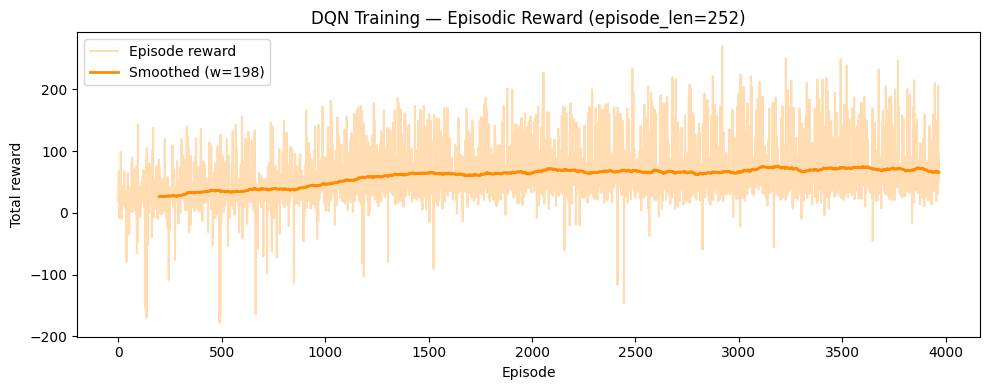

Reward curve saved to /content/drive/MyDrive/results/dqn_252_reward_curve.png


In [44]:
# Plot training reward curve
rewards = callback.ep_rewards
print(f'Total episodes: {len(rewards)}')

if rewards:
    window   = max(1, len(rewards) // 20)
    smoothed = np.convolve(rewards, np.ones(window) / window, mode='valid')

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(rewards,  alpha=0.3, color='darkorange', label='Episode reward')
    ax.plot(range(window - 1, len(rewards)), smoothed,
            color='darkorange', linewidth=2, label=f'Smoothed (w={window})')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total reward')
    ax.set_title(f'DQN Training — Episodic Reward (episode_len={EPISODE_LEN})')
    ax.legend()
    fig.tight_layout()
    fig.savefig(CURVE_SAVE, dpi=150)
    plt.show()
    print(f'Reward curve saved to {CURVE_SAVE}')

## 8. Evaluate on 2019–2026 (Out-of-Sample)

In [45]:
def compute_metrics(portfolio_values, label):
    daily_rets   = np.diff(portfolio_values) / portfolio_values[:-1]
    total_return = (portfolio_values[-1] - portfolio_values[0]) / portfolio_values[0]
    mean_r = daily_rets.mean()
    std_r  = daily_rets.std(ddof=1)
    sharpe = (mean_r / std_r * np.sqrt(252)) if std_r > 0 else 0.0
    neg_rets = daily_rets[daily_rets < 0]
    down_std = neg_rets.std(ddof=1) if len(neg_rets) > 1 else 1e-10
    sortino  = (mean_r / down_std * np.sqrt(252)) if down_std > 0 else 0.0
    peak     = np.maximum.accumulate(portfolio_values)
    drawdown = (peak - portfolio_values) / np.where(peak > 0, peak, 1)
    max_dd   = drawdown.max()
    win_rate = (daily_rets > 0).mean()
    return {'label': label, 'total_return': total_return, 'sharpe': sharpe,
            'sortino': sortino, 'max_drawdown': max_dd, 'win_rate': win_rate}


def run_buy_and_hold(prices, initial_cash):
    return (initial_cash / prices[0]) * prices


def run_always_cash(prices, initial_cash):
    return np.full(len(prices), initial_cash, dtype=np.float64)


def run_fixed_threshold(prices, probs, initial_cash):
    cash, shares, pos = initial_cash, 0.0, 0.0
    values = []
    for price, prob in zip(prices, probs):
        if prob > 0.6:   pos = 1.0
        elif prob < 0.4: pos = 0.0
        total         = cash + shares * price
        target_shares = pos * total / price
        delta         = target_shares - shares
        if delta > 0:
            cost = min(delta * price, cash)
            shares += cost / price
            cash   -= cost
        elif delta < 0:
            sell    = min(abs(delta), shares)
            shares -= sell
            cash   += sell * price
        values.append(cash + shares * price)
    return np.array(values, dtype=np.float64)


def run_dqn_eval(prices, probs, extra_features, dqn_model, initial_cash=10_000):
    """Run DQN as a single continuous episode over the full test period."""
    env = NASDAQTradingEnv(prices, probs, extra_features,
                           initial_cash=initial_cash,
                           episode_len=len(prices) - 1)
    env._start = 0
    env._step_count = 0
    env._cash   = initial_cash
    env._shares = 0.0
    obs = env._get_obs()

    portfolio_values = [initial_cash]
    actions_list     = []

    done = False
    while not done:
        action, _ = dqn_model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        portfolio_values.append(env._total_assets())
        actions_list.append(int(action))

    return np.array(portfolio_values, dtype=np.float64), np.array(actions_list)


print('Evaluation helpers defined.')

Evaluation helpers defined.


In [46]:
INITIAL_CASH = 10_000.0

# Build out-of-sample test set (2019-2026)
n = len(df)
t2, t3 = int(n * 0.80), int(n * 0.90)
eval_df = df.iloc[t2:].reset_index(drop=True)
print(f'Eval split: {len(eval_df)} rows  '
      f'({eval_df["Date"].iloc[0]} to {eval_df["Date"].iloc[-1]})')

# Generate LSTM signals for test period
print('\nGenerating rolling LSTM signals for test data...')
test_probs, test_prices, test_extra = generate_prob_series(eval_df, model_lstm, scaler)
print(f'Test arrays — probs: {test_probs.shape}, prices: {test_prices.shape}')

# Load DQN (in case kernel was restarted after training)
dqn_model = DQN.load(DQN_SAVE)
print(f'DQN loaded from {DQN_SAVE}')

# Run evaluation
print('\nRunning DQN evaluation...')
dqn_values, dqn_act = run_dqn_eval(test_prices, test_probs, test_extra, dqn_model, INITIAL_CASH)

# Baselines
bah_values  = run_buy_and_hold(test_prices, INITIAL_CASH)
cash_values = run_always_cash(test_prices,  INITIAL_CASH)
thr_values  = run_fixed_threshold(test_prices, test_probs, INITIAL_CASH)

# Align lengths
n_steps     = min(len(dqn_values), len(bah_values))
dqn_values  = dqn_values[:n_steps]
bah_values  = bah_values[:n_steps]
cash_values = cash_values[:n_steps]
thr_values  = thr_values[:n_steps]

print(f'Evaluation complete  ({n_steps} steps)')

Eval split: 1770 rows  (2019-02-04 to 2026-02-18)

Generating rolling LSTM signals for test data...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Generated 1710 steps  |  raw prob: mean=0.673 std=0.123  |  norm prob: mean=0.486 std=0.328
Test arrays — probs: (1710,), prices: (1710,)
DQN loaded from /content/drive/MyDrive/models/dqn_nasdaq_252.zip

Running DQN evaluation...
Evaluation complete  (1710 steps)


In [47]:
# Print metrics table
results = [
    compute_metrics(dqn_values,  f'DQN (ep={EPISODE_LEN}d)'),
    compute_metrics(bah_values,  'Buy & Hold'),
    compute_metrics(cash_values, 'Always Cash'),
    compute_metrics(thr_values,  'Fixed Threshold'),
]

header = f"{'Strategy':<25} {'Total Ret':>10} {'Sharpe':>8} {'Sortino':>8} {'Max DD':>9} {'Win Rate':>9}"
sep    = '-' * len(header)
print(f'\n{sep}')
print(header)
print(sep)
for r in results:
    print(f"{r['label']:<25} "
          f"{r['total_return']:>9.2%} "
          f"{r['sharpe']:>8.3f} "
          f"{r['sortino']:>8.3f} "
          f"{r['max_drawdown']:>8.2%} "
          f"{r['win_rate']:>8.2%}")
print(sep)



--------------------------------------------------------------------------
Strategy                   Total Ret   Sharpe  Sortino    Max DD  Win Rate
--------------------------------------------------------------------------
DQN (ep=252d)               510.90%    0.954    1.087   35.65%   51.14%
Buy & Hold                  182.67%    0.751    0.971   36.40%   55.65%
Always Cash                   0.00%    0.000    0.000    0.00%    0.00%
Fixed Threshold             134.57%    0.699    0.643   34.97%   27.15%
--------------------------------------------------------------------------


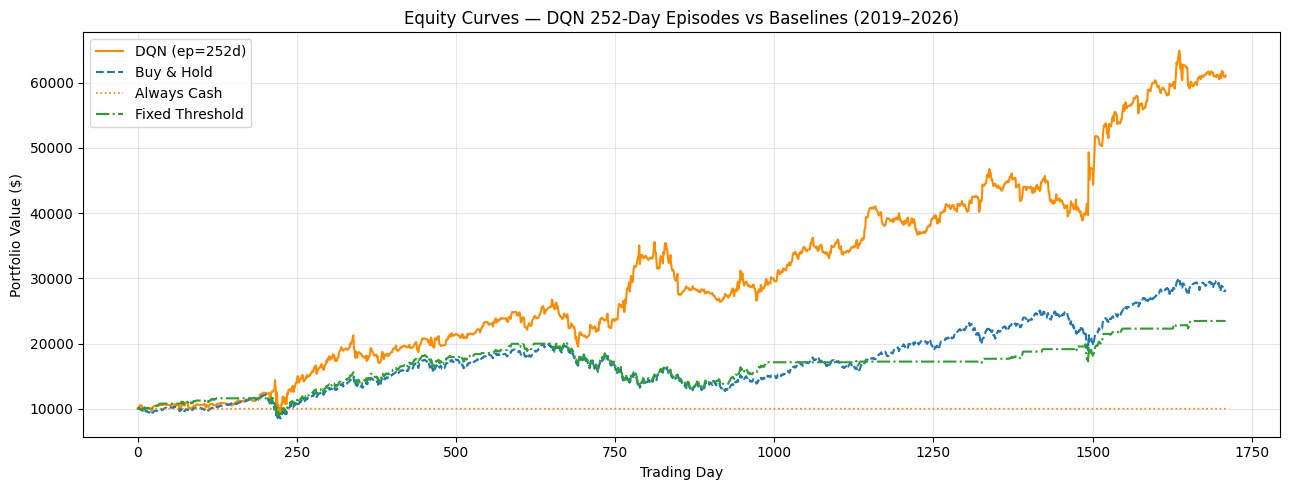

Equity curves saved to /content/drive/MyDrive/results/dqn_252_equity_curves.png

Action distribution (% of steps):
  action  0 (pos=-1.0):   0.1%
  action  1 (pos=-0.9):   7.8%
  action  2 (pos=-0.8):  11.8%
  action  3 (pos=-0.7):   0.1%
  action  5 (pos=-0.5):   0.9%
  action  6 (pos=-0.4):   4.8%
  action  7 (pos=-0.3):   8.5%
  action  9 (pos=-0.1):   2.8%
  action 10 (pos=+0.0):   6.0%
  action 11 (pos=+0.1):   0.2%
  action 12 (pos=+0.2):   0.3%
  action 13 (pos=+0.3):   1.0%
  action 14 (pos=+0.4):   1.1%
  action 15 (pos=+0.5):  11.9%
  action 16 (pos=+0.6):   0.1%
  action 17 (pos=+0.7):   2.0%
  action 18 (pos=+0.8):   0.4%
  action 19 (pos=+0.9):   0.1%
  action 20 (pos=+1.0):   2.1%
  action 22 (pos=+1.2):   0.3%
  action 24 (pos=+1.4):   2.2%
  action 25 (pos=+1.5):   2.6%
  action 26 (pos=+1.6):   0.2%
  action 27 (pos=+1.7):   6.1%
  action 28 (pos=+1.8):   0.2%
  action 29 (pos=+1.9):   8.0%
  action 30 (pos=+2.0):  18.4%


In [48]:
# Plot equity curves
days = np.arange(n_steps)
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(days, dqn_values,  label=f'DQN (ep={EPISODE_LEN}d)', linewidth=1.5, color='darkorange')
ax.plot(days, bah_values,  label='Buy & Hold',                linewidth=1.5, linestyle='--')
ax.plot(days, cash_values, label='Always Cash',               linewidth=1.2, linestyle=':')
ax.plot(days, thr_values,  label='Fixed Threshold',           linewidth=1.5, linestyle='-.')
ax.set_xlabel('Trading Day')
ax.set_ylabel('Portfolio Value ($)')
ax.set_title(f'Equity Curves — DQN {EPISODE_LEN}-Day Episodes vs Baselines (2019–2026)')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(EQUITY_SAVE, dpi=150)
plt.show()
print(f'Equity curves saved to {EQUITY_SAVE}')

# Action distribution
print('\nAction distribution (% of steps):')
actions, counts = np.unique(dqn_act, return_counts=True)
for action, count in zip(actions, counts):
    pos = ACTION_MAP[action]
    print(f'  action {action:2d} (pos={pos:+.1f}): {count / len(dqn_act):6.1%}')